DATA UNDERSTANDING

1. LOAD DATA

In [37]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


df = pd.read_csv("online_retail.csv")

In [38]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [39]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


2. CHECK MISSING VALUE & DUPLICATE

In [41]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [42]:
total = df.duplicated().sum()
print(f"Total Duplicate value = ", total)

Total Duplicate value =  5268


3.CHECK NEGATIVE VALUE

In [43]:
p =(df["Quantity"] < 0).sum()
print(f"Total Negative value in column Quantity : ", p)

Total Negative value in column Quantity :  10624


4. CHECK OUTLAYER

In [44]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Number of Outliers: {len(outliers)}")


Column: Quantity
Number of Outliers: 58619

Column: UnitPrice
Number of Outliers: 39627

Column: CustomerID
Number of Outliers: 0


DATA WRANGLING


In [45]:
df_clean = df.copy()

1. CHANGE DATA TYPE

In [46]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


2. DROP DUPLICATED VALUES

In [47]:
df_clean = df_clean.drop_duplicates()

2. FEATURE ENGINEERING FOR MISSING VALUES AND ANOMALIES VALUES

In [48]:
df_clean["Is_Return"] = (df_clean["Quantity"] <= 0).astype(int)
df_clean["Has_CustomerID"] = df_clean["CustomerID"].notna().astype(int)
df_clean["InvoiceHour"] = df_clean["InvoiceDate"].dt.hour

3. NEW COLOUMN TOTAL PRICE

In [49]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

FEATURE SELECTION

In [50]:
features = [ #yang akan digunakan untuk model KMeans
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "Is_Return",
    "Has_CustomerID",
    "InvoiceHour",
]

EXPLORATORY DATA ANALYSIS

In [51]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,536641.0,9.620029,-80995.0,1.0,3.0,10.0,80995.0,219.130156
InvoiceDate,536641,2011-07-04 08:57:06.087421952,2010-12-01 08:26:00,2011-03-28 10:52:00,2011-07-19 14:04:00,2011-10-18 17:05:00,2011-12-09 12:50:00,NaN
UnitPrice,536641.0,4.632656,-11062.06,1.25,2.08,4.13,38970.0,97.233118
CustomerID,401604.0,15281.160818,12346.0,13939.0,15145.0,16784.0,18287.0,1714.006089
Is_Return,536641.0,0.019728,0.0,0.0,0.0,0.0,1.0,0.139065
Has_CustomerID,536641.0,0.748366,0.0,0.0,1.0,1.0,1.0,0.433952
InvoiceHour,536641.0,13.077154,6.0,11.0,13.0,15.0,20.0,2.447505
TotalPrice,536641.0,18.123861,-168469.6,3.75,9.87,17.4,168469.6,380.656263


1. Numerical Variable Distribution

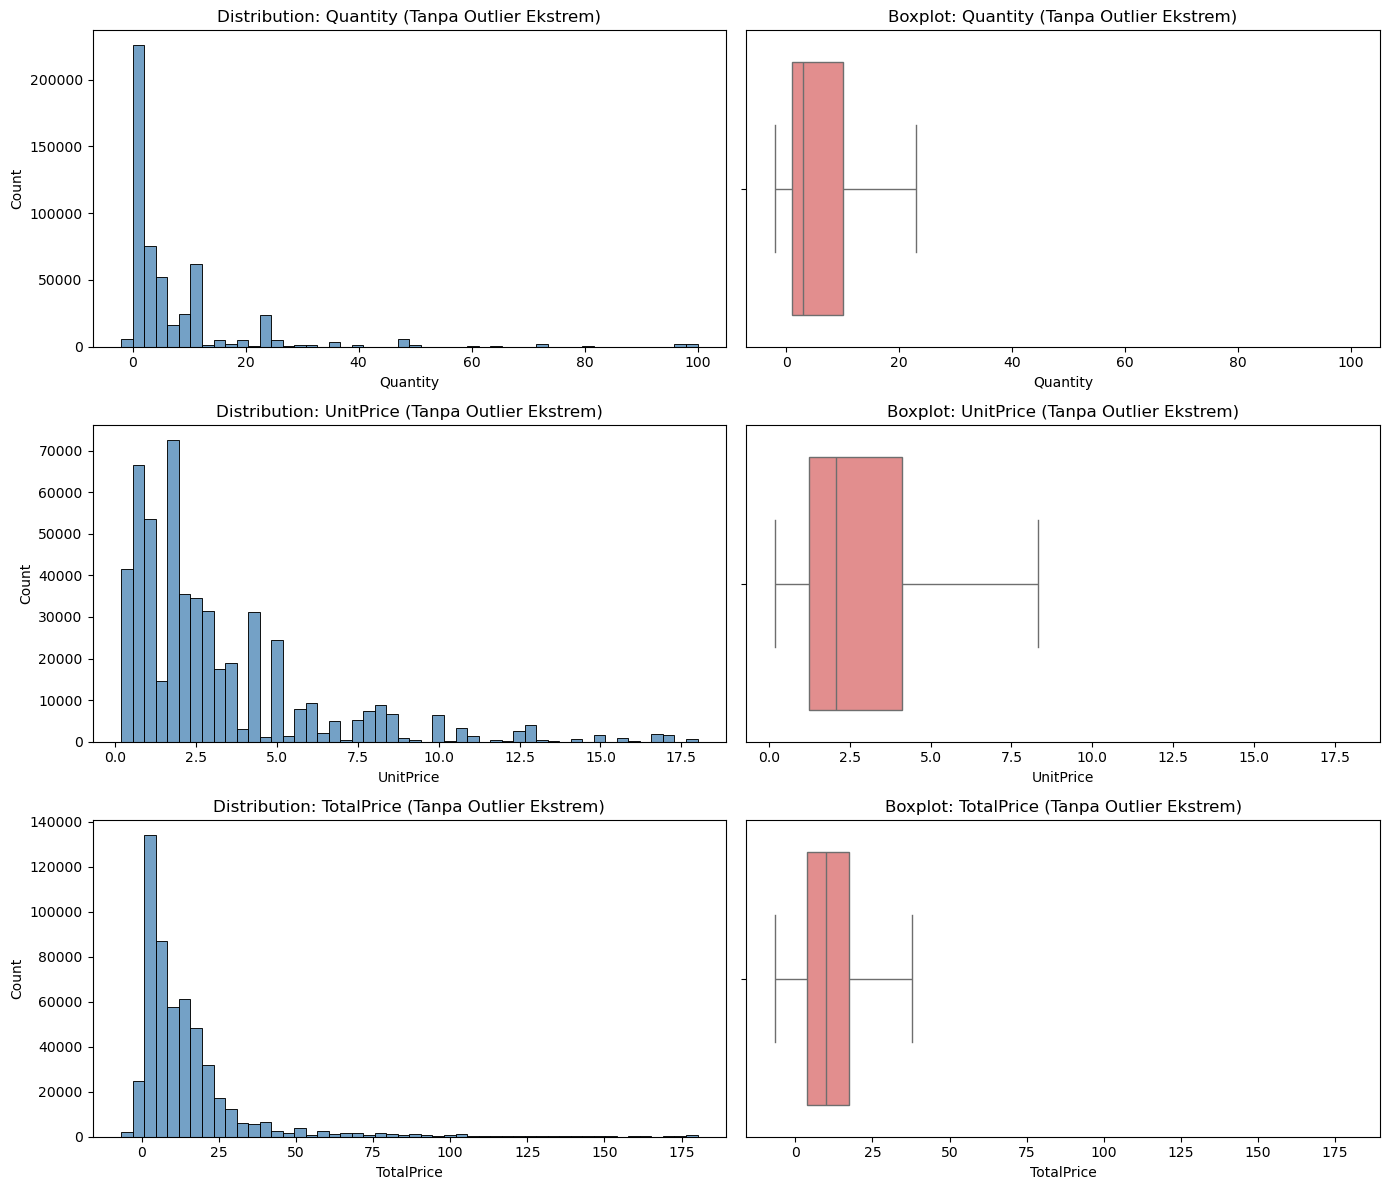

In [52]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    # FILTER VISUALISASI: Buang 1% nilai paling bawah dan 1% nilai paling atas
    q_low = df_clean[col].quantile(0.01)
    q_hi = df_clean[col].quantile(0.99)
    data_filtered = df_clean[(df_clean[col] >= q_low) & (df_clean[col] <= q_hi)][col]
    
    # 1. HISTOGRAM 
    sns.histplot(data_filtered, kde=False, bins=50, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'Distribution: {col} (Tanpa Outlier Ekstrem)')
    axes[i][0].set_xlabel(col)

    # 2. BOXPLOT
    sns.boxplot(x=data_filtered, ax=axes[i][1], color='lightcoral', fliersize=0)
    axes[i][1].set_title(f'Boxplot: {col} (Tanpa Outlier Ekstrem)')
    axes[i][1].set_xlabel(col)

plt.tight_layout()
plt.show()

2. TOP SELLING PRODUCT & TOP REVENUE PRODUCT

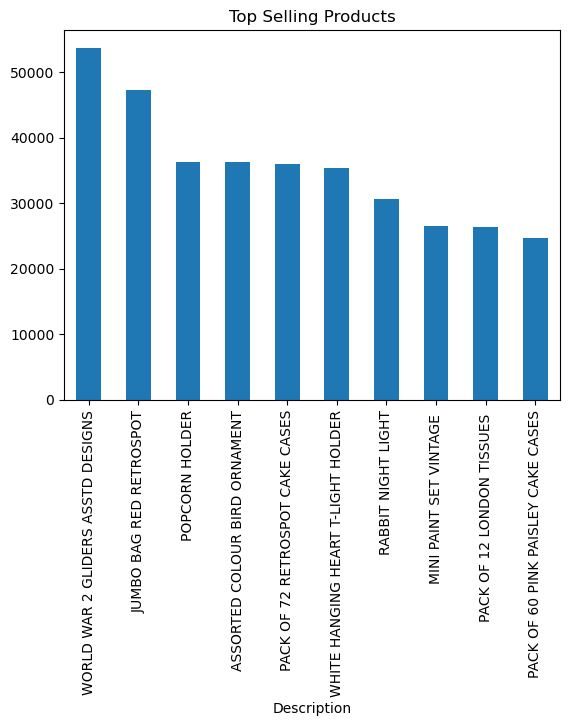

In [53]:
top_products = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")
plt.title("Top Selling Products")
plt.show()

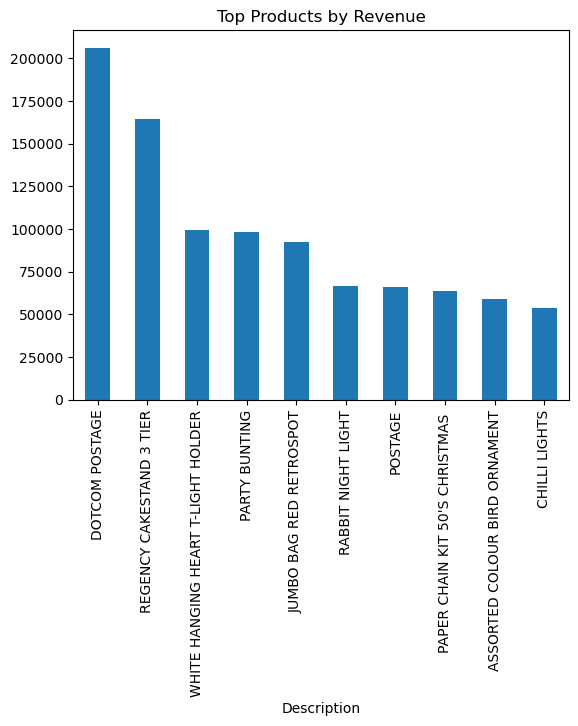

In [54]:
top_revenue = df_clean.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

top_revenue.plot(kind="bar")
plt.title("Top Products by Revenue")
plt.show()

3. SALES BY COUNTRY

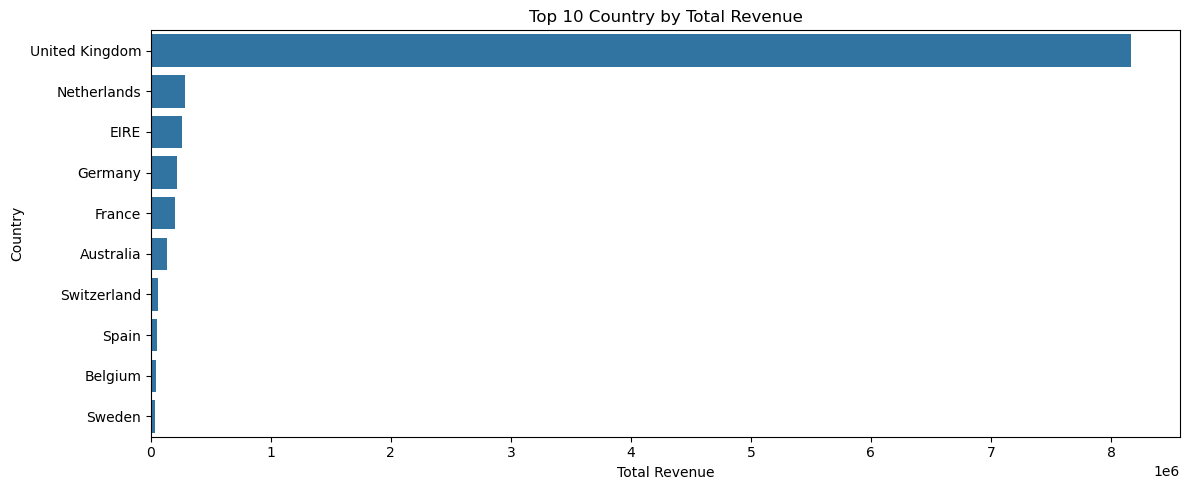

In [55]:
country_sales = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title('Top 10 Country by Total Revenue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

4. SALES TREND & TIME ANALYSIS

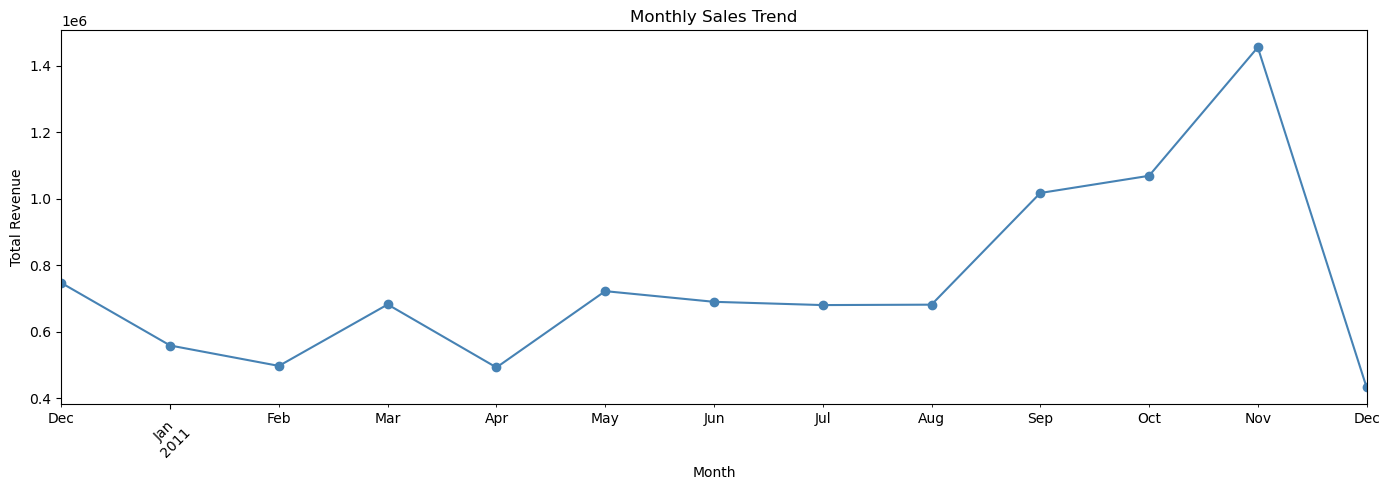

In [56]:
monthly_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

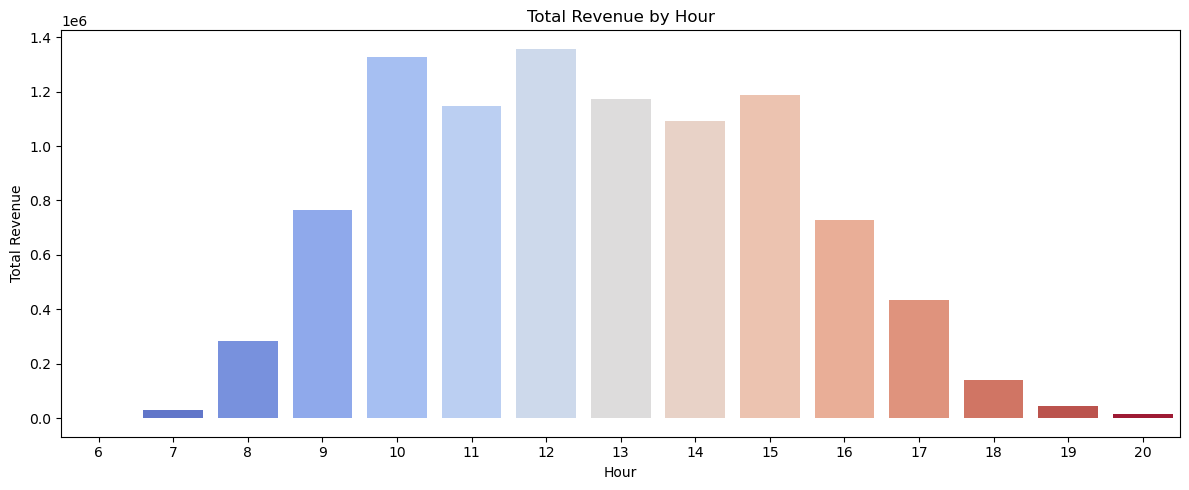

In [57]:
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hour_sales = df_clean.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=hour_sales.index, y=hour_sales.values, hue=hour_sales.index, palette='coolwarm', legend=False)
plt.title('Total Revenue by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

5.CUSTOMER SPENDING

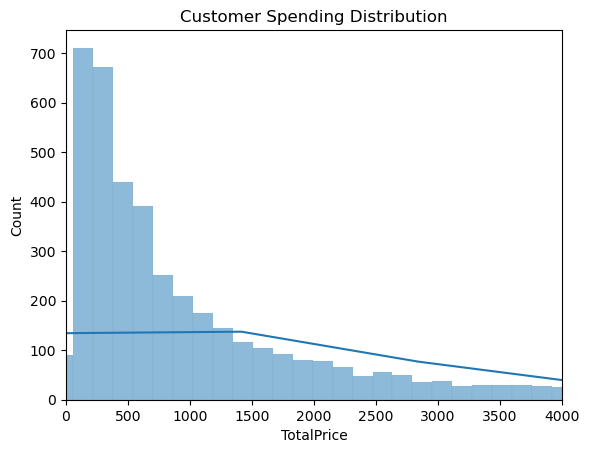

In [58]:
customer_spending = df_clean.groupby("CustomerID")["TotalPrice"].sum()

sns.histplot(customer_spending, kde=True)
plt.xlim(left =0 )
plt.xlim(right = 4000)
plt.title("Customer Spending Distribution")
plt.show()

6. CORRELATION

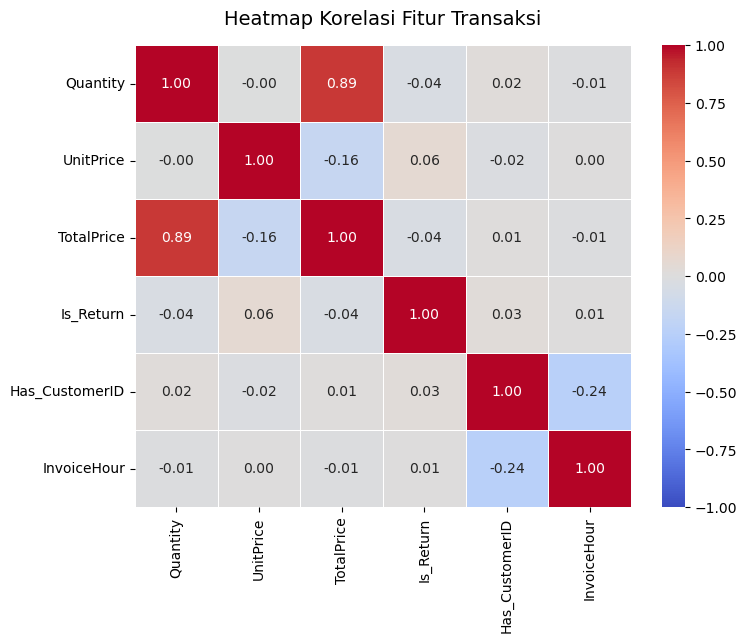

In [59]:
# 1. Hitung matriks korelasi
corr_matrix = df_clean[features].corr()

# 2. Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,
    linewidths=0.5,  
)

plt.title("Heatmap Korelasi Fitur Transaksi", fontsize=14, pad=15)
plt.show()

Transformation Data & Scaling

1. Redam skala nilai ekstrem (outlier) tanpa membuang baris data

In [60]:
from sklearn.preprocessing import QuantileTransformer

df_clean["Quantity_log"] = np.sign(df_clean["Quantity"]) * np.log1p(
    np.abs(df_clean["Quantity"])
)
df_clean["UnitPrice_log"] = np.log1p(
    np.abs(df_clean["UnitPrice"])
)  # Ditambahkan np.abs() di sini
df_clean["TotalPrice_log"] = np.sign(df_clean["TotalPrice"]) * np.log1p(
    np.abs(df_clean["TotalPrice"])
)

2. Kumpulkan semua fitur yang akan dimasukkan ke model

In [61]:
features_log = [
    "Quantity_log",
    "UnitPrice_log",
    "TotalPrice_log",
    "Is_Return",
    "Has_CustomerID",
    "InvoiceHour",
]

In [62]:
qt = QuantileTransformer(output_distribution="normal", random_state=42)
X_scaled = qt.fit_transform(df_clean[features_log])

KMeans Modeling & Evaluation

1. Modeling

In [63]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

2. Hasil Clustering

In [64]:
print("\n=== RINGKASAN CLUSTER TRANSAKSI ===")
print(
    df_clean.groupby("Cluster")
    .agg(
        Jumlah_Baris=("InvoiceNo", "count"),
        Rata_Quantity=("Quantity", "mean"),
        Rata_UnitPrice=("UnitPrice", "mean"),
        Rata_TotalPrice=("TotalPrice", "mean"),
        Persen_Retur=("Is_Return", lambda x: round(x.mean() * 100, 2)),
        Persen_Member=("Has_CustomerID", lambda x: round(x.mean() * 100, 2)),
    )
    .round(2)
)


=== RINGKASAN CLUSTER TRANSAKSI ===
         Jumlah_Baris  Rata_Quantity  Rata_UnitPrice  Rata_TotalPrice  \
Cluster                                                                 
0              133322           3.59            6.07            13.00   
1              176106           2.51            3.17             5.95   
2              216626          21.81            3.09            36.19   
3               10587         -45.58           42.44           -84.44   

         Persen_Retur  Persen_Member  
Cluster                               
0                 0.0            0.0  
1                 0.0          100.0  
2                 0.0          100.0  
3               100.0           83.8  


3. Evaluation

In [65]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
labels = df_clean["Cluster"]

# 1. Silhouette Score (Menggunakan sample_size agar tidak membebani RAM)
# Mengukur seberapa dekat titik data dengan cluster-nya sendiri dibanding cluster lain.
# Rentang -1 sampai 1. Semakin mendekati 1 semakin baik.
sil_score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)

# 2. Davies-Bouldin Index (DBI)
# Mengukur rata-rata rasio kesamaan tiap cluster dengan cluster yang paling mirip.
# Semakin KECIL nilainya, semakin baik pemisahan cluster-nya.
db_score = davies_bouldin_score(X_scaled, labels)

# 3. Calinski-Harabasz Index (Variance Ratio Criterion)
# Rasio antara dispersi (penyebaran) antar-cluster vs dalam-cluster.
# Semakin BESAR nilainya, semakin baik dan solid cluster tersebut.
ch_score = calinski_harabasz_score(X_scaled, labels)

print("=== EVALUASI MODEL K-MEANS (k=4) ===")
print(f"Silhouette Score      : {sil_score:.4f} (Mendekati 1 = Baik)")
print(f"Davies-Bouldin Index  : {db_score:.4f} (Semakin kecil = Baik)")
print(f"Calinski-Harabasz     : {ch_score:.2f} (Semakin besar = Baik)")

=== EVALUASI MODEL K-MEANS (k=4) ===
Silhouette Score      : 0.3994 (Mendekati 1 = Baik)
Davies-Bouldin Index  : 0.9329 (Semakin kecil = Baik)
Calinski-Harabasz     : 1358238.46 (Semakin besar = Baik)
